# Bibliotecas necessarias 


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Análise de Desempenho de Estudantes 

## O nosso dataset fizemos download do Kaggle e trata-se do Desempenho dos alunos nos exames de matemática, leitura e escrita ao fim do ensino médio.



### Inicialmente vamos abrir o arquivo e associasr a uma variavel que vai ser o nosso dataframe

In [3]:
desempenho = pd.read_csv('StudentsPerformance.csv')
desempenho.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Agora vamos verificar os tipos de variáveis que temos.

In [4]:
desempenho.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Temos 7 variáveis ao qual vou chamar de atributos sendo que 4 desse atributos são nominais (gender,race/ethnicity,parental level of education,lunch,test preparation course) e três são numericos (math score, reading score,writing score)

Vamos verificar as possíveis classificações (que vou chamar de rótulos) desses atributos nominais. 

In [5]:
desempenho['gender'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [6]:
desempenho['race/ethnicity'].unique()

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

In [7]:
desempenho['parental level of education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [8]:
desempenho['lunch'].unique()

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

In [9]:
desempenho['test preparation course'].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

Para tornar nosso projeto mais interessante e melhor compreensível vamos passar os atributos e os seus rotulos todos para o idioma português. 

## No código abaixo nos vamos alterar os nomes dos atributos de inglês para português.

In [10]:
desempenho = desempenho.rename(columns={
    'gender': 'genero',
    'race/ethnicity': 'raca_etnia',
    'parental level of education': 'nivel_educacao_pais',
    'lunch': 'tipo_alimentacao',
    'test preparation course': 'curso_preparatorio',
    'math score': 'nota_matematica',
    'reading score': 'nota_leitura',
    'writing score': 'nota_escrita'
})

## Nos códigos abaixo vamos alterar os nomes dos rotulos de inglês para português.

In [11]:
desempenho['genero'] = desempenho['genero'].replace({
    'female': 'feminino',
    'male': 'masculino'
})

In [12]:
desempenho['tipo_alimentacao'] = desempenho['tipo_alimentacao'].replace({
    'standard': 'padrao',
    'free/reduced': 'gratuito/reduzido'
})

In [13]:
desempenho['curso_preparatorio'] = desempenho['curso_preparatorio'].replace({
    'none': 'nenhum',
    'completed': 'completo'
})

In [14]:
desempenho['nivel_educacao_pais'] = desempenho['nivel_educacao_pais'].replace({
    "bachelor's degree": 'ensino_superior',
    "some college": 'faculdade_incompleta',
    "master's degree": 'mestrado',
    "associate's degree": 'tecnico',
    "high school": 'ensino_medio',
    "some high school": 'medio_incompleto'
})

In [15]:
desempenho['raca_etnia'] = desempenho['raca_etnia'].replace({
    'group A': 'grupo_A',
    'group B': 'grupo_B',
    'group C': 'grupo_C',
    'group D': 'grupo_D',
    'group E': 'grupo_E'
})

# Agora vamos ver novamente as cinco primeiras linhas de nosso dataframe traduzido para o português.

In [16]:
desempenho.head()


,genero,raca_etnia,nivel_educacao_pais,tipo_alimentacao,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,feminino,grupo_B,ensino_superior,padrao,nenhum,72,72,74
1,feminino,grupo_C,faculdade_incompleta,padrao,completo,69,90,88
2,feminino,grupo_B,mestrado,padrao,nenhum,90,95,93
3,masculino,grupo_A,tecnico,gratuito/reduzido,nenhum,47,57,44
4,masculino,grupo_C,faculdade_incompleta,padrao,nenhum,76,78,75


# Agora vamos verificar se temos linhas com falta de informação ou com informação nula.

In [92]:
desempenho.isnull().sum()

genero                  0
raca_etnia              0
nivel_educacao_pais     0
tipo_alimentacao        0
curso_preparatorio      0
nota_matematica         0
nota_leitura            0
nota_escrita            0
nivel_educacao_pais2    0
dtype: int64

# Vamos descrever as estatísticas básicas dos atributos notas de matematica, leitura e escrita de uma maneira geral sem agrupamentos.

In [17]:
desempenho.describe()

,nota_matematica,nota_leitura,nota_escrita
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Vamos começar nossas analises primeiro vamos verificar a porcentagem de meninas e meninas que participaram dos testes

In [19]:
desempenho['genero'].value_counts(normalize=True)*100



genero
feminino     51.8
masculino    48.2
Name: proportion, dtype: float64

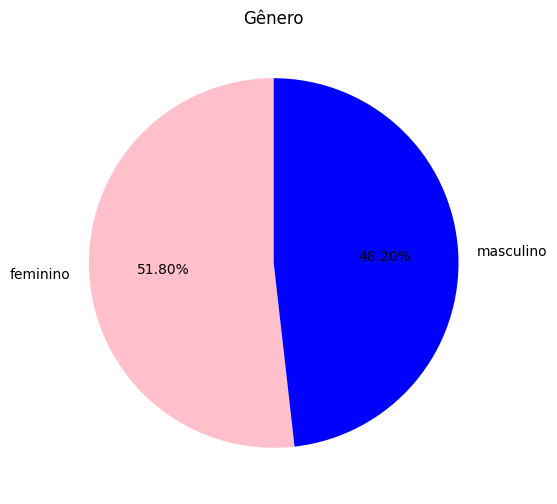

In [22]:
plt.figure(figsize = (18,6))
plt.pie(desempenho['genero'].value_counts(),colors=['pink','blue'],labels=['feminino','masculino'],autopct='%1.2f%%',startangle=90)
plt.title("Gênero")
plt.show()

Podemos observar pelo percentual e pelo gráfico de pizza que tivemos mais mulheres fazendo o teste do que homens.

# Agora vamos fazer uma análise do desempenho das notas por gênero

Abaixo temos as tabelas com as médias, medianas e desvio padrão por gênero e teste.

In [95]:
desempenho.groupby(['genero'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
genero,,,
feminino,63.63,72.61,72.47
masculino,68.73,65.47,63.31


In [94]:
desempenho.groupby(['genero'])[['nota_matematica','nota_leitura','nota_escrita']].median()

,nota_matematica,nota_leitura,nota_escrita
genero,,,
feminino,65.0,73.0,74.0
masculino,69.0,66.0,64.0


In [97]:
desempenho.groupby(['genero'])[['nota_matematica','nota_leitura','nota_escrita']].std().round(2)

,nota_matematica,nota_leitura,nota_escrita
genero,,,
feminino,15.49,14.38,14.84
masculino,14.36,13.93,14.11


Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em matemática, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, os homens tem um desempenho um pouco melhor do que as mulheres no teste de matemática.Temos uma variabilidade maior das notas em matemática das mulheres em relação ao homens.temos também uma diferença no desempenho medio das mulheres em relação aos homens em leitura, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de leitura.Observa-se também que temos uma diferença no desempenho medio das mulheres em relação aos homens em escrita, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de escrita. vamos tentar visualizar isso em um famos gráfico de Boxplot.

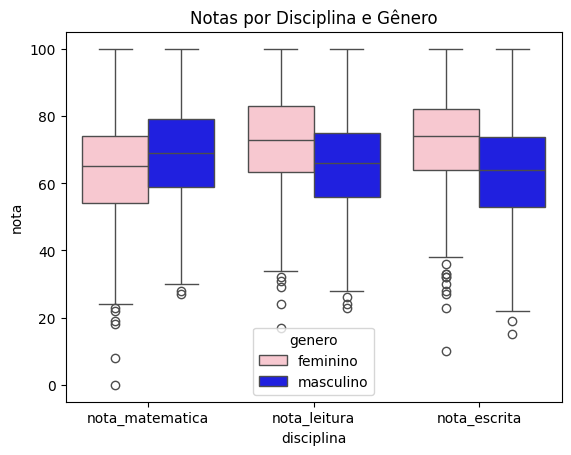

In [ ]:
box_junto = desempenho.melt(
    id_vars='genero',
    value_vars=['nota_matematica','nota_leitura','nota_escrita'],
    var_name='disciplina',
    value_name='nota'
)

sns.boxplot(
    data=box_junto,
    x='disciplina',
    y='nota',
    hue='genero',
    palette=['pink','blue']
)

plt.title('Notas por Disciplina e Gênero')
plt.show()


Podemos visualizar novamente uma peguena diferença de desempenho em matemática a favor dos homens ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.A variabilidade maior das notas de matemática para mulheres deve-se algumas valores que estão bem abaixo do primeiro quartil. Podemos observar uma diferença de desempenho em leitura a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens. Ja neste caso a variabilidade continua sendo maior que a dos homens, mas a mediana é acima da média o que eleva a quantidade de notas altas das mulheres.E por último temos uma diferença de desempenho em escrita a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.Acredito que das três comparações esse tenha a diferença mais significativa.

# Porcentagem de pessoas que fizeram os testes por Raça/Etnia

In [33]:
desempenho['raca_etnia'].value_counts(normalize=True)*100

raca_etnia
grupo_C    31.9
grupo_D    26.2
grupo_B    19.0
grupo_E    14.0
grupo_A     8.9
Name: proportion, dtype: float64

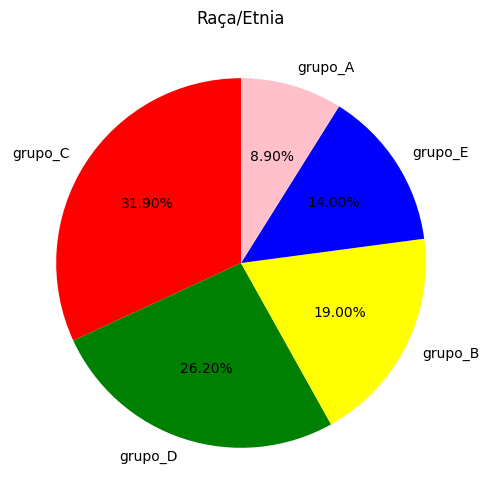

In [35]:
plt.figure(figsize = (18,6))
plt.pie(desempenho['raca_etnia'].value_counts(),colors=['red','green','yellow','blue','pink'],labels=['grupo_C','grupo_D','grupo_B','grupo_E','grupo_A'],autopct='%1.2f%%',startangle=90)
plt.title("Raça/Etnia")
plt.show()

De acordo com as porcentagens e com o gráfico podemos ver que os grupos etnicos C e D somam mais de 50% dos participantes.

# Vamos analisar o desempenho nos testes em relação aos grupos etnicos

In [43]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,61.63,64.67,62.67
grupo_B,63.45,67.35,65.60
grupo_C,64.46,69.10,67.83
grupo_D,67.36,70.03,70.15
grupo_E,73.82,73.03,71.41


In [42]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].median()

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,61.0,64.0,62.0
grupo_B,63.0,67.0,67.0
grupo_C,65.0,71.0,68.0
grupo_D,69.0,71.0,72.0
grupo_E,74.5,74.0,72.0


In [99]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].std().round(2)

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,14.52,15.54,15.47
grupo_B,15.47,15.18,15.63
grupo_C,14.85,14.00,14.98
grupo_D,13.77,13.90,14.37
grupo_E,15.53,14.87,15.11


Aqui vou manipular as colunas do dataframe para criar um gráfico de barras e facilitar nosso entendimento

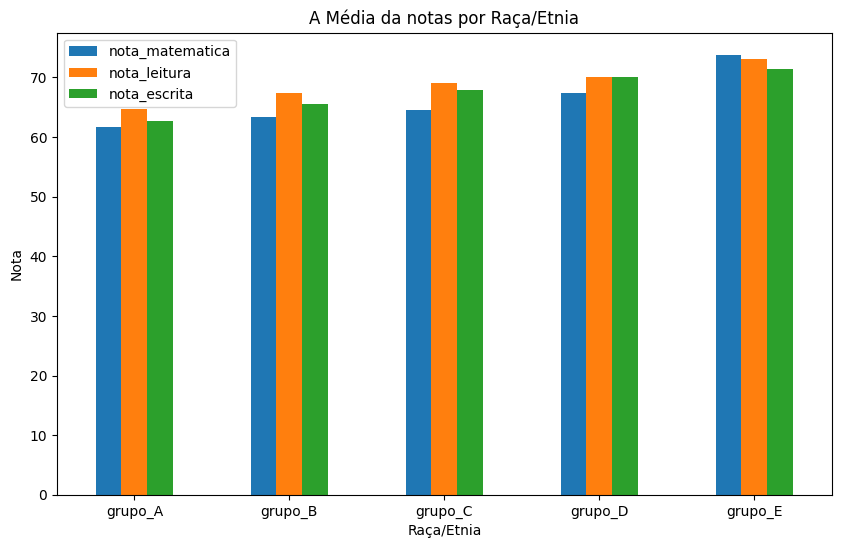

In [41]:
colunas = ['nota_matematica','nota_leitura','nota_escrita']
media_por_grupo = desempenho.groupby('raca_etnia')[colunas].mean()
media_por_grupo.plot(kind='bar',figsize=(10,6))
plt.title("A Média da notas por Raça/Etnia")
plt.ylabel('Nota')
plt.xlabel('Raça/Etnia')
plt.xticks(rotation = 0)
plt.show()

Através dos dados e observando o gráfico de barras, podemos sugerir que o grupo etnico E teve um desempenho melhor em todas as provas ao comparar com os outros grupos etnicos, já o grupo etnico A teve um desempenho inferior a todos os outros grupos etnicos.

# Porcentagem de alunos participantes dos testes de acordo o nível de educação dos pais.

In [ ]:
desempenho['nivel_educacao_pais'].value_counts(normalize=True)*100

nivel_educacao_pais
faculdade_incompleta    22.6
tecnico                 22.2
ensino_medio            19.6
medio_incompleto        17.9
ensino_superior         11.8
mestrado                 5.9
Name: proportion, dtype: float64

Podemos verificar pela tabela que a grande maioria dos participantes dos testes eram filhos de pais com nivel de educação ensino medio, tecnico e faculdade incompleta (algo em torno de 60%).

# vamos fazer algumas verificações no desempenho dos alunos em função do nível de educação de seus pais em cada teste.

In [101]:
desempenho.groupby(['nivel_educacao_pais'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
nivel_educacao_pais,,,
ensino_medio,62.14,64.70,62.45
ensino_superior,69.39,73.00,73.38
faculdade_incompleta,67.13,69.46,68.84
medio_incompleto,63.50,66.94,64.89
mestrado,69.75,75.37,75.68
tecnico,67.88,70.93,69.90


In [102]:
desempenho.groupby(['nivel_educacao_pais'])[['nota_matematica','nota_leitura','nota_escrita']].median().round(2)

,nota_matematica,nota_leitura,nota_escrita
nivel_educacao_pais,,,
ensino_medio,63.0,66.0,64.0
ensino_superior,68.0,73.0,74.0
faculdade_incompleta,67.5,70.5,70.0
medio_incompleto,65.0,67.0,66.0
mestrado,73.0,76.0,75.0
tecnico,67.0,72.5,70.5


In [103]:
desempenho.groupby(['nivel_educacao_pais'])[['nota_matematica','nota_leitura','nota_escrita']].std().round(2)

,nota_matematica,nota_leitura,nota_escrita
nivel_educacao_pais,,,
ensino_medio,14.54,14.13,14.09
ensino_superior,14.94,14.29,14.73
faculdade_incompleta,14.31,14.06,15.01
medio_incompleto,15.93,15.48,15.74
mestrado,15.15,13.78,13.73
tecnico,15.11,13.87,14.31


In [105]:
desempenho.groupby(['genero','nivel_educacao_pais'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

nota_matematica  nota_leitura  nota_escrita
genero    nivel_educacao_pais                                              
feminino  ensino_medio                    59.35         68.20         66.69
          ensino_superior                 68.35         77.29         78.38
          faculdade_incompleta            65.41         73.55         74.05
          medio_incompleto                59.30         69.11         68.29
          mestrado                        66.50         76.81         77.64
          tecnico                         65.25         74.12         74.00
masculino ensino_medio                    64.71         61.48         58.54
          ensino_superior                 70.58         68.09         67.65
          faculdade_incompleta            69.01         64.99         63.15
          medio_incompleto                67.84         64.69         61.38
          mestrado                        74.83         73.13         72.61
          tecnico                         70.76         67.43         65.41

Aqui podemos observar que de acordo que o nível de instrução dos pais temos um aumento no desempenho dos alunos em suas notas médias.Vamos ver isso melhor em um gráfico.

Para fazer essa avaliação visual de uma maneira bem intuitiva, vamos ter que fazer uma ordenação nos rótulos das coluna de nivel de educação dos pais.E para isso vamos criar uma coluna especificamente para utilizar nesses gráficos.Essa coluna será chamada de nivel_educacao_pais2.

In [48]:
ordenado = [ 'medio_incompleto','ensino_medio','tecnico','faculdade_incompleta','ensino_superior','mestrado']
desempenho['nivel_educacao_pais2'] = pd.Categorical(desempenho['nivel_educacao_pais'],categories=ordenado, ordered = True)
grafico_linha = desempenho.groupby(['genero','nivel_educacao_pais2'])[['nota_matematica','nota_leitura','nota_escrita']].mean().reset_index()

Agora que colocamos os rotulos em ordem e criamos a nova coluna vamos traçar o gráfico de linha.

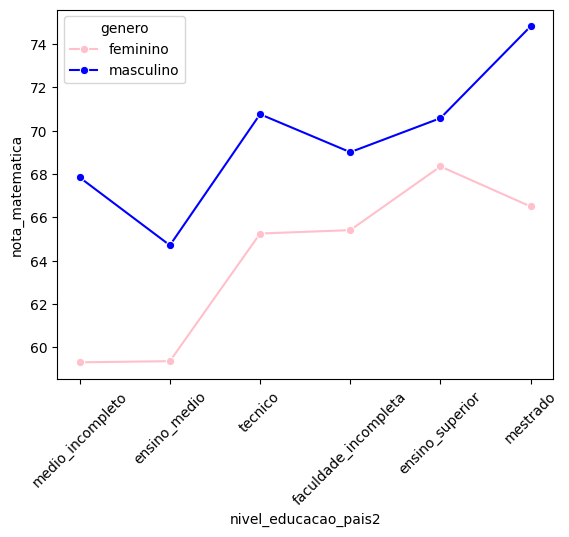

In [54]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_matematica', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

E interessante observar que intuitivamente esperavamos esse comportamento desse gráfico, ou seja conforme o nível de instrução dos país se eleva o desempenho dos alunos seja maior.Outra observação é que as o desempenho dos meninos quando seus pais tem formação superior incompleta ou acima suas notas evoluem de uma maneira rápida. O que surpreende é essa mudança drástica no caso do desempenho das notas das meninas quando seus pais tem mestrado.

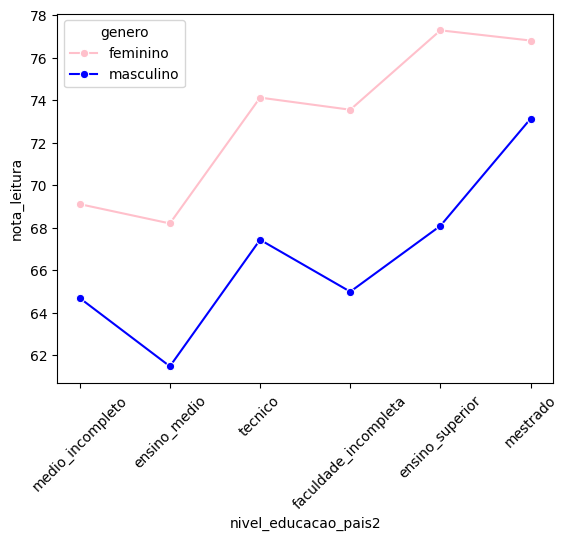

In [53]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_leitura', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

Como já tinhamos visto as meninas em geral tem o desempenho melhor em leitura do os meninos, mas o que surpreende nesse gráfico é a mudança brusca das notas dos meninos ou seja quando os pais tem uma faculdade incompleta ou acima disso o desempenho dos meninos em leitura aumenta bruscamente.

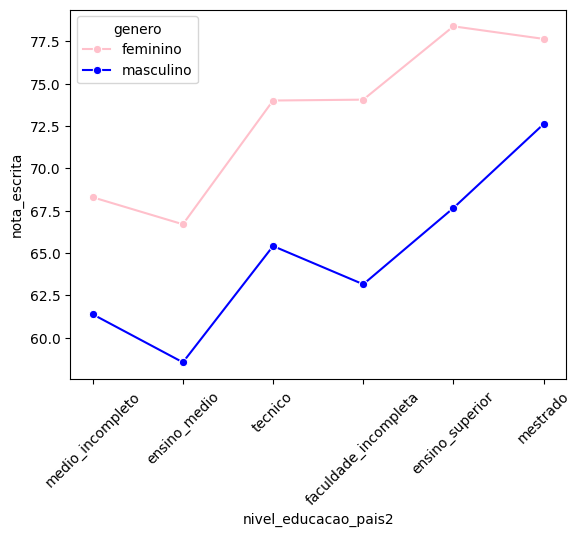

In [58]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_escrita', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

Como já tinhamos visto as meninas em geral tem o desempenho melhor em escrita do que os meninos, mas o que surpreende nesse gráfico é a mudança brusca das notas dos meninos ou seja quando os pais tem uma faculdade incompleta ou acima disso o desempenho dos meninos escrita aumenta bruscamente.

# Vamos analisar agora a questão da alimentação com o desempenho.

In [50]:
desempenho['tipo_alimentacao'].value_counts(normalize=True)*100

tipo_alimentacao
padrao               64.5
gratuito/reduzido    35.5
Name: proportion, dtype: float64

Nos testes tivemos uma participação maior de alunos que fazem uma alimentação padrão do que uma alimentação reduzida/gratuita.

In [70]:
desempenho.groupby(['tipo_alimentacao'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
tipo_alimentacao,,,
gratuito/reduzido,58.92,64.65,63.02
padrao,70.03,71.65,70.82


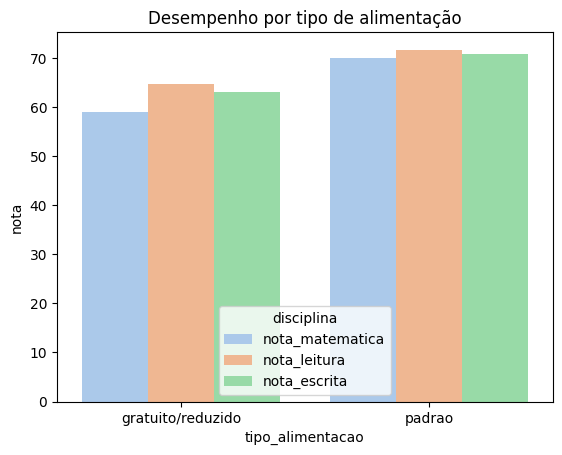

In [76]:
media_alimentacao = desempenho.groupby(['tipo_alimentacao'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)
media_alimentacao = media_alimentacao.reset_index()
media_corrida = media_alimentacao.melt(id_vars='tipo_alimentacao', var_name='disciplina',value_name= 'nota')
sns.barplot(
    data=media_corrida,
    x='tipo_alimentacao',
    y='nota',
    hue='disciplina',
    palette='pastel'
)
plt.title('Desempenho por tipo de alimentação')
plt.show()

E visível que os alunos que se alimentam com a alimentação padrão teve um desempenho superior em todas os testes.Isto é a alimentação reduzida/gratuita não ajuda no desempenho das notas dos alunos.

# Agora vamos analisar a relação do curso preparatório no desempenho das notas do alunos.

In [51]:
desempenho['curso_preparatorio'].value_counts(normalize=True)*100

curso_preparatorio
nenhum      64.2
completo    35.8
Name: proportion, dtype: float64

Aqui temos as tabelas de desempenho dos alunos com curso preparatório e sem o curso preparatório.

In [74]:
desempenho.groupby(['curso_preparatorio'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
curso_preparatorio,,,
completo,69.70,73.89,74.42
nenhum,64.08,66.53,64.50


Ja nessa tabela abaixo temos o desempenho dos alunos separados por genero com e sem curso preparatório.

In [91]:
desempenho.groupby(
    ['genero', 'curso_preparatorio']
)[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)


nota_matematica  nota_leitura  nota_escrita
genero    curso_preparatorio                                             
feminino  completo                      67.20         77.38         78.79
          nenhum                        61.67         69.98         68.98
masculino completo                      72.34         70.21         69.79
          nenhum                        66.69         62.80         59.65

Agora temos os gráficos das duas tabelas

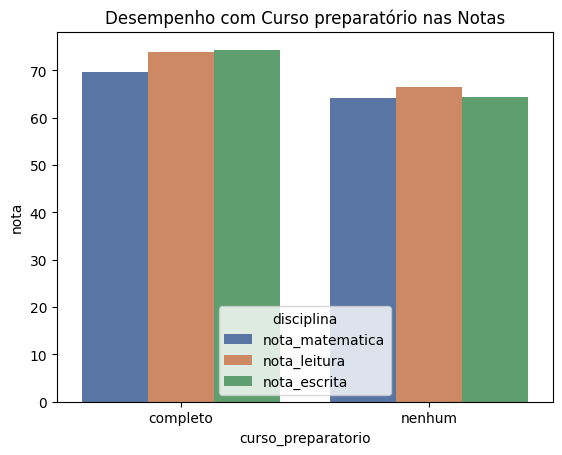

In [83]:
media_preparação = desempenho.groupby(['curso_preparatorio'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)
media_preparação = media_preparação.reset_index()
media_prep = media_preparação.melt(id_vars='curso_preparatorio', var_name='disciplina',value_name= 'nota')
sns.barplot(
    data=media_prep,
    x='curso_preparatorio',
    y='nota',
    hue='disciplina',
    palette='deep'
)
plt.title('Desempenho com Curso preparatório nas Notas')
plt.show()

Podemos ver que em geral os alunos que fizeram um curso preparatório tiveram um desempenho melhor do que aqueles que não fizeram. E uma diferença bem significativa para o desempenho.

Vamos verificar o desempenho das notas por genero para quem fez o curso preparatorio ou não.

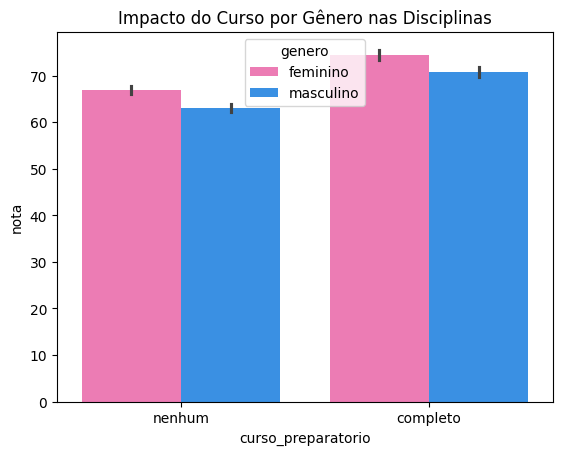

In [88]:
analise_preparatorio = desempenho.melt(
    id_vars=['genero', 'curso_preparatorio'],
    value_vars=['nota_matematica','nota_leitura','nota_escrita'],
    var_name='disciplina',
    value_name='nota')
sns.barplot(
    data=analise_preparatorio,
    x='curso_preparatorio',
    y='nota',
    hue='genero',
    palette={'feminino': '#FF69B4',
             'masculino':  '#1E90FF'}
)

plt.title('Impacto do Curso por Gênero nas Disciplinas')
plt.show()

Temos através das tabelas e dos gráficos a confirmação de uma intuição ao qual alunos que fazem um curso preparatório desempenham melhor nos testes tendo em vista sua médias aumentarem, quando separamos por gênero podemos ver que os aumentos no teste de leitura e escrita são bem maiores do que em matemática para ambos os sexos. Avaliar se o aumento é mais significativo para os homens do que para mulheres através dessas médias não é uma dedução simples, haja vista essas diferenças (com ou sem curso preparatório) entre as médias dos gêneros não é significativa.